In [1]:
import sys
import os
import numpy as np

In [2]:
import os
os.chdir(os.path.expanduser(r"H:\GitHub\KalmanFilter"))
from python.data.generate_lane_data import generate_highway_data, LaneDataset

In [3]:
print("Generating A9 → A8 highway interchange dataset …")
ds = generate_highway_data(dt=0.04, duration=120.0, seed=42, sigma_camera=0.05)
print(f"  {ds.T} frames  |  dt={ds.dt}s  |  {ds.T*ds.dt:.0f}s total")
print(f"  Dropouts:  left={np.isnan(ds.meas_L).sum()}  right={np.isnan(ds.meas_R).sum()}")


Generating A9 → A8 highway interchange dataset …
  3000 frames  |  dt=0.04s  |  120s total
  Dropouts:  left=82  right=103


In [6]:
from python.filters.kf  import KalmanFilter
from python.utils.metrics import rmse, mae, nis_statistics, print_metrics_table
from python.utils.visualization import (
    plot_c0_comparison,
    plot_state_components,
    plot_nis,
    plot_rmse_per_phase,
    PHASE_LABELS,
)

In [4]:
ds.save_csv("data/lane_data.csv")

Saved 3000 frames → data/lane_data.csv


In [7]:
#  Process noise std-devs:  (σ_C0, σ_C1, σ_C2, σ_C3)
SIGMA_PROCESS = (0.04, 0.004, 4e-5, 8e-7)
SIGMA_CAMERA  = 0.05   # m   — camera C0 detection noise

In [8]:

def run_filter(filt, ds: LaneDataset, side: str = "L"):
    """
    Run a filter over the full dataset for one lane side.

    Returns arrays:
        x0, x1, x2, x3   — state estimates at each step
        nis_vals          — NIS per step
    """
    meas = ds.meas_L if side == "L" else ds.meas_R
    C0_init = ds.C0_L_true[0] if side == "L" else ds.C0_R_true[0]

    # Initialise state: [C0, C1=0, C2=0, C3=0]
    x0_init = np.array([C0_init, 0.0, 0.0, 0.0])
    P0_init = np.diag([0.1, 0.01, 1e-4, 1e-6])
    filt.initialize(x0_init, P0_init)

    T = ds.T
    out_x = np.full((T, 4), np.nan)
    out_nis = np.full(T, np.nan)

    for k in range(T):
        u  = np.array([ds.speed[k], ds.yaw_rate[k]])
        dt = ds.dt

        # --- Predict ---
        if isinstance(filt, KalmanFilter):
            filt.predict()
        else:
            filt.predict(u=u, dt=dt)

        # --- Update (skip if measurement missing) ---
        z = meas[k]
        if not np.isnan(z):
            filt.update(np.array([z]))
            out_nis[k] = filt.NIS

        out_x[k] = filt.x

    return out_x, out_nis


In [44]:
# ------------- KF -------------
SIGMA_PROCESS = (0.07, 0.004, 4e-5, 8e-7)
SIGMA_CAMERA  = 0.1

kf_L = KalmanFilter.build_lane_filter(ds.dt, SIGMA_PROCESS, SIGMA_CAMERA)
kf_R = KalmanFilter.build_lane_filter(ds.dt, SIGMA_PROCESS, SIGMA_CAMERA)
kf_out_L, kf_nis_L = run_filter(kf_L, ds, "L")
kf_out_R, kf_nis_R = run_filter(kf_R, ds, "R")


# ------------- EKF -------------
ekf_L = ExtendedKalmanFilter.build_lane_filter(ds.dt, SIGMA_PROCESS, SIGMA_CAMERA)
ekf_R = ExtendedKalmanFilter.build_lane_filter(ds.dt, SIGMA_PROCESS, SIGMA_CAMERA)
ekf_out_L, ekf_nis_L = run_filter(ekf_L, ds, "L")
ekf_out_R, ekf_nis_R = run_filter(ekf_R, ds, "R")

# ------------- UKF -------------
ukf_L = UnscentedKalmanFilter.build_lane_filter(ds.dt, SIGMA_PROCESS, SIGMA_CAMERA,
                                                  alpha=1e-3, beta=2.0, kappa=0.0)
ukf_R = UnscentedKalmanFilter.build_lane_filter(ds.dt, SIGMA_PROCESS, SIGMA_CAMERA,
                                                  alpha=1e-3, beta=2.0, kappa=0.0)
ukf_out_L, ukf_nis_L = run_filter(ukf_L, ds, "L")
ukf_out_R, ukf_nis_R = run_filter(ukf_R, ds, "R")

In [45]:
def valid_nis(arr):
    return arr[~np.isnan(arr)]

results = {
    "KF":  {"rmse_L": rmse(kf_out_L[:, 0],  ds.C0_L_true),
             "rmse_R": rmse(kf_out_R[:, 0],  ds.C0_R_true),
             "mae_L":  mae(kf_out_L[:, 0],   ds.C0_L_true),
             "mae_R":  mae(kf_out_R[:, 0],   ds.C0_R_true)},
        "EKF": {"rmse_L": rmse(ekf_out_L[:, 0], ds.C0_L_true),
             "rmse_R": rmse(ekf_out_R[:, 0], ds.C0_R_true),
             "mae_L":  mae(ekf_out_L[:, 0],  ds.C0_L_true),
             "mae_R":  mae(ekf_out_R[:, 0],  ds.C0_R_true)},
        "UKF": {"rmse_L": rmse(ukf_out_L[:, 0], ds.C0_L_true),
             "rmse_R": rmse(ukf_out_R[:, 0], ds.C0_R_true),
             "mae_L":  mae(ukf_out_L[:, 0],  ds.C0_L_true),
             "mae_R":  mae(ukf_out_R[:, 0],  ds.C0_R_true)},
}
print_metrics_table(results)

# NIS consistency
print("\nNIS Consistency (should have mean ≈ 1 for m=1):")
for name, nis_arr in [("KF",  kf_nis_L), ("EKF", ekf_nis_L), ("UKF", ukf_nis_L)]:
    stats = nis_statistics(valid_nis(nis_arr), obs_dim=1)
    flag  = " consistent" if stats["consistent"] else "INCONSISTENT"
    print(f"  {name:<4} mean_NIS={stats['mean_NIS']:.3f}  "
          f"(low={stats['ci_lo']:.1f}, " f"high={stats['ci_hi']:.1f}, "
          f"expected={stats['expected']:.1f}) --> model is{flag}")

# Per-phase RMSE
print("\nPer-phase RMSE — C0_L:")
phase_rmse = {name: {} for name in results}
for ph in range(1, 6):
    mask = ds.phase_mask(ph)
    for name, arr in [("KF", kf_out_L), ("EKF", ekf_out_L), ("UKF", ukf_out_L)]:
        phase_rmse[name][ph] = rmse(arr[mask, 0], ds.C0_L_true[mask])
    print(f"  Phase {ph}  KF={phase_rmse['KF'][ph]:.4f} "
          f"EKF={phase_rmse['EKF'][ph]:.4f}  UKF={phase_rmse['UKF'][ph]:.4f}  m")


Filter   | RMSE_L (m) | RMSE_R (m) |  MAE_L (m) |  MAE_R (m)
KF       |     0.0710 |     0.0727 |     0.0395 |     0.0410
EKF      |     0.0772 |     0.0791 |     0.0428 |     0.0446
UKF      |     0.0772 |     0.0791 |     0.0428 |     0.0446

NIS Consistency (should have mean ≈ 1 for m=1):
  KF   mean_NIS=0.986  (low=0.9, high=1.1, expected=1.0) --> model is consistent
  EKF  mean_NIS=0.987  (low=0.9, high=1.1, expected=1.0) --> model is consistent
  UKF  mean_NIS=0.986  (low=0.9, high=1.1, expected=1.0) --> model is consistent

Per-phase RMSE — C0_L:
  Phase 1  KF=0.0763 EKF=0.0839  UKF=0.0839  m
  Phase 2  KF=0.0833 EKF=0.0901  UKF=0.0901  m
  Phase 3  KF=0.0616 EKF=0.0660  UKF=0.0660  m
  Phase 4  KF=0.0622 EKF=0.0672  UKF=0.0672  m
  Phase 5  KF=0.0679 EKF=0.0739  UKF=0.0739  m



NIS Consistency (should have mean ≈ 1 for m=1):
  KF   mean_NIS=3.701  (expected=1.0)  ✗ INCONSISTENT

Per-phase RMSE — C0_L:
  Phase 1  KF=0.0809  m
  Phase 2  KF=0.0880  m
  Phase 3  KF=0.0654  m
  Phase 4  KF=0.0659  m
  Phase 5  KF=0.0721  m


In [13]:
sigma_process = (0.05, 0.005, 5e-5, 1e-6)
q = np.array(sigma_process) ** 2
Q = np.diag(q)

In [14]:
print(q)

[2.5e-03 2.5e-05 2.5e-09 1.0e-12]


In [15]:
Q

array([[2.5e-03, 0.0e+00, 0.0e+00, 0.0e+00],
       [0.0e+00, 2.5e-05, 0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00, 2.5e-09, 0.0e+00],
       [0.0e+00, 0.0e+00, 0.0e+00, 1.0e-12]])

In [16]:
R = np.array([[0.05 ** 2]])

Saved → plots/c0_comparison.png
Saved → plots/state_components.png

Plots saved to ./plots/


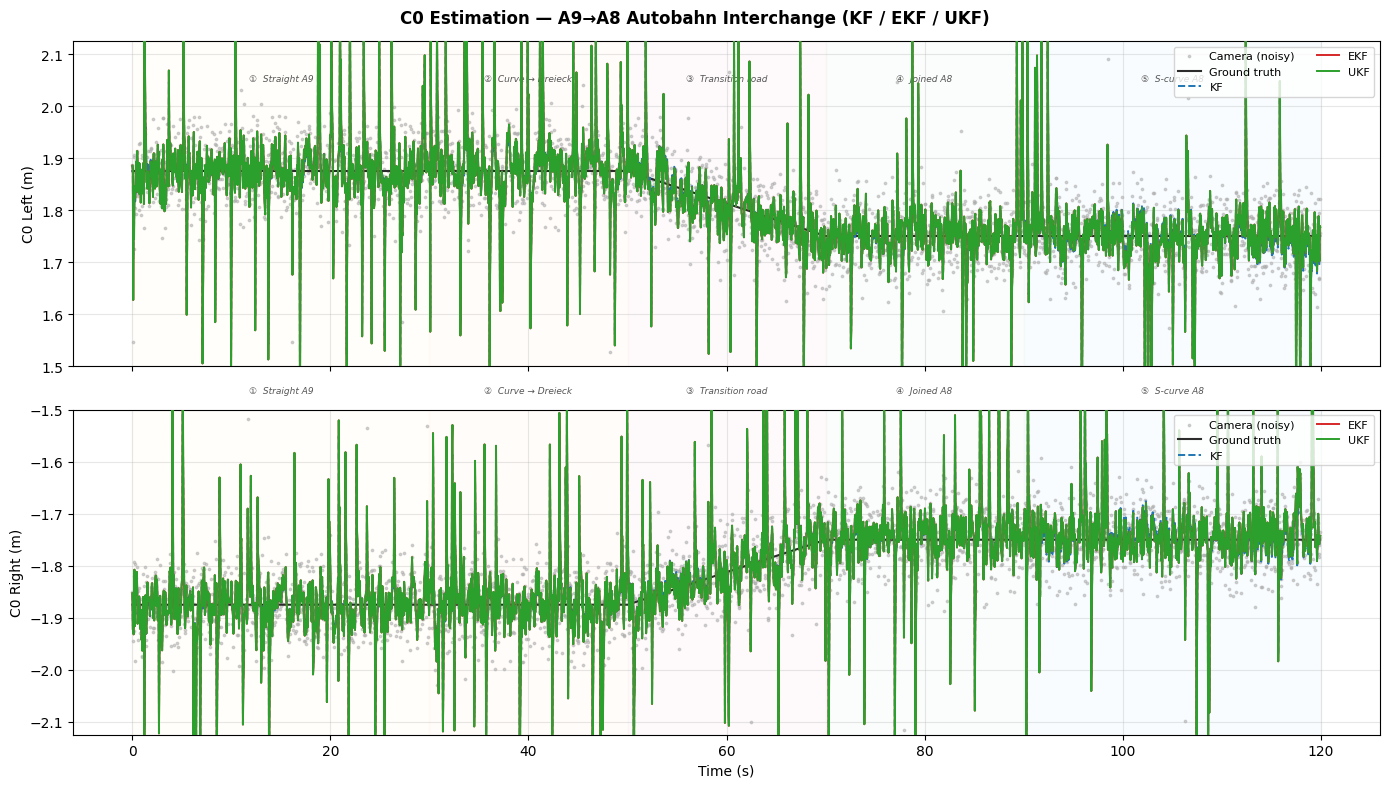

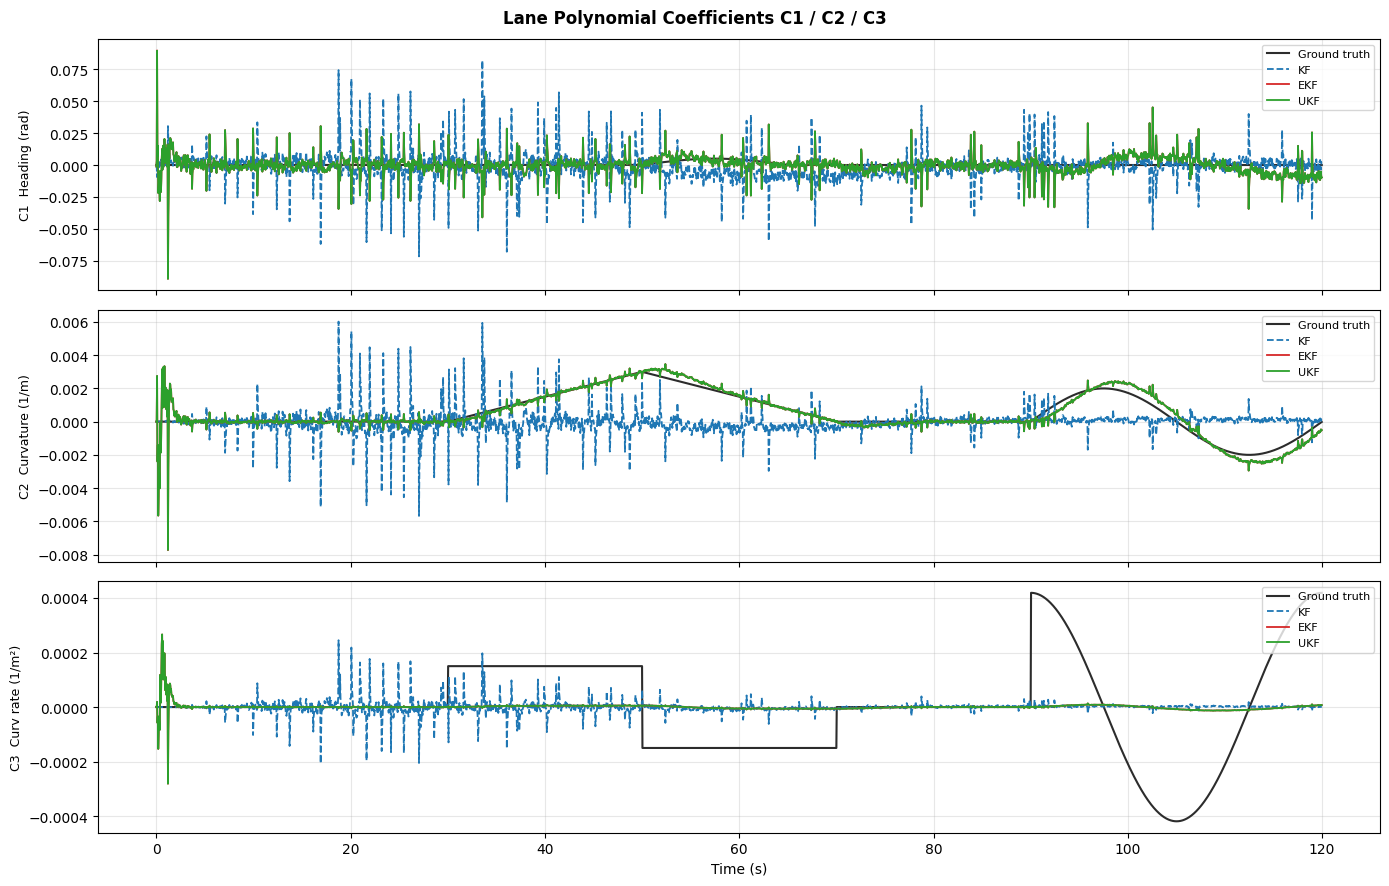

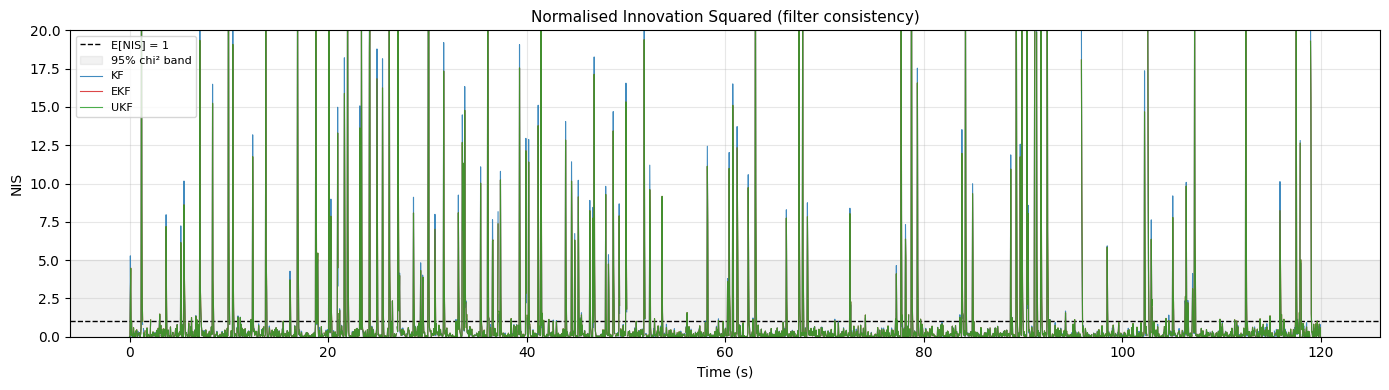

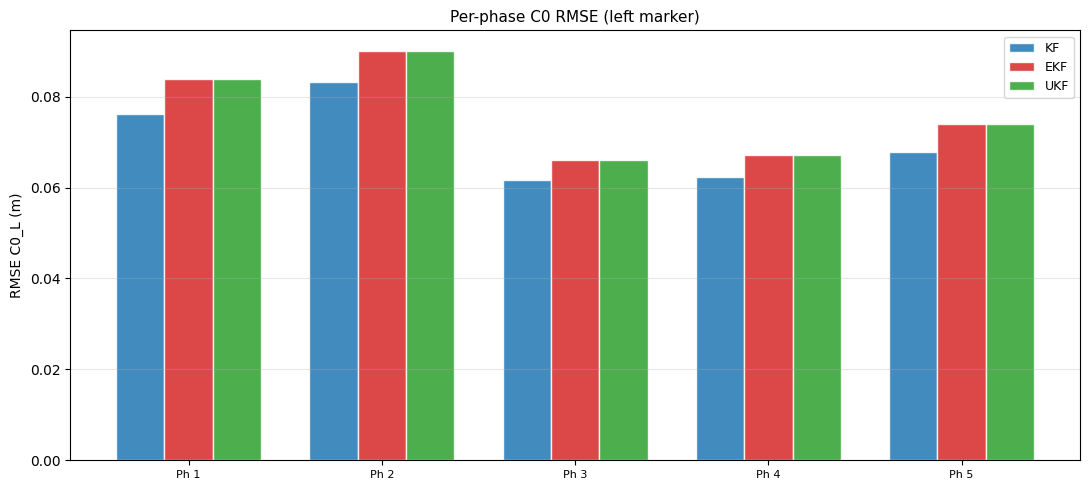

In [46]:

estimates = {
    "KF":  {"C0_L": kf_out_L[:, 0],  "C0_R": kf_out_R[:, 0],
             "C1":   kf_out_L[:, 1],  "C2":   kf_out_L[:, 2], "C3": kf_out_L[:, 3]},
    "EKF": {"C0_L": ekf_out_L[:, 0], "C0_R": ekf_out_R[:, 0],
             "C1":   ekf_out_L[:, 1], "C2":   ekf_out_L[:, 2], "C3": ekf_out_L[:, 3]},
    "UKF": {"C0_L": ukf_out_L[:, 0], "C0_R": ukf_out_R[:, 0],
             "C1":   ukf_out_L[:, 1], "C2":   ukf_out_L[:, 2], "C3": ukf_out_L[:, 3]},
}

os.makedirs("plots", exist_ok=True)

fig1 = plot_c0_comparison(
    ds.t, ds.C0_L_true, ds.C0_R_true,
    ds.meas_L, ds.meas_R,
    estimates,
    title="C0 Estimation — A9→A8 Autobahn Interchange (KF / EKF / UKF)",
    save_path="plots/c0_comparison.png",
)

fig2 = plot_state_components(
    ds.t, ds.C1_true, ds.C2_true, ds.C3_true,
    estimates,
    save_path="plots/state_components.png",
)

fig3 = plot_nis(
    ds.t,
    nis_dict={"KF": kf_nis_L, "EKF": ekf_nis_L, "UKF": ukf_nis_L},
    obs_dim=1,
    save_path="plots/nis.png",
)

fig4 = plot_rmse_per_phase(
    phase_rmse,
    phase_labels=[f"Ph {i}" for i in range(1, 6)],
    save_path="plots/rmse_per_phase.png",
)

print("\nPlots saved to ./plots/")
